# 03 — Model Eğitimi ve Değerlendirme
**BA Degree Project 2 — Credit Scoring ML** · Batuhan SEN · 200527078

Dokümanın **Methodology 5.4–5.5** bölümlerini uygular. 4 modeli karşılaştırır:
Logistic Regression (baseline), Random Forest, XGBoost, LightGBM.

**Pipeline (her model):** `SMOTE (CV fold içinde) → model`, RandomizedSearchCV (5-fold, n_iter=100).
**Metrikler:** AUC-ROC (primary), Gini, F1/Precision/Recall (optimal threshold), paired t-test, SHAP.

## 1. Setup

In [1]:
import pandas as pd, numpy as np, os, time, warnings, joblib
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt, seaborn as sns
%matplotlib inline
sns.set_style("whitegrid"); plt.rcParams["figure.dpi"]=110

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import (RandomizedSearchCV, StratifiedKFold,
                                     cross_val_score, cross_val_predict)
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score, precision_score,
                             recall_score, confusion_matrix)
from scipy import stats
from itertools import combinations

if os.path.basename(os.getcwd())=="notebooks": os.chdir("..")
RANDOM_STATE=42
N_ITER=100           # methodology 5.6: 100 parametre kombinasyonu
FIG_DIR="outputs/figures"; RES_DIR="outputs/results"
os.makedirs(FIG_DIR,exist_ok=True); os.makedirs(RES_DIR,exist_ok=True)

d=joblib.load("data/processed/prepared_50k.joblib")
X_train,X_test=d["X_train"],d["X_test"]; y_train,y_test=d["y_train"],d["y_test"]
print(f"Train {X_train.shape} · Test {X_test.shape} · N_ITER={N_ITER}")

Train (40000, 23) · Test (10000, 23) · N_ITER=100


## 2. Model Konfigürasyonları (Methodology 5.4, Table 5.2)

SMOTE her pipeline'ın içinde — RandomizedSearchCV bunu **yalnız training fold'una** uygular
(validation fold'u sentetik veriyle kirlenmez = leakage yok).

In [2]:
smote=SMOTE(random_state=RANDOM_STATE)
configs={
 "Logistic Regression":(ImbPipeline([("sc",StandardScaler()),("sm",smote),
    ("clf",LogisticRegression(max_iter=1000,random_state=RANDOM_STATE))]),
    {"clf__C":np.logspace(-3,2,20)}),                          # C: 0.001-100 log
 "Random Forest":(ImbPipeline([("sm",smote),
    ("clf",RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=1))]),
    {"clf__n_estimators":[100,200,300,500],"clf__max_depth":[5,10,15,20],
     "clf__min_samples_split":[5,10,20,50],"clf__max_features":["sqrt","log2",0.5]}),
 "XGBoost":(ImbPipeline([("sm",smote),
    ("clf",XGBClassifier(random_state=RANDOM_STATE,eval_metric="logloss",n_jobs=1,verbosity=0))]),
    {"clf__learning_rate":[0.01,0.05,0.1,0.3],"clf__max_depth":[3,5,7,10],
     "clf__reg_alpha":[0,1,5,10],"clf__reg_lambda":[0,1,5,10],
     "clf__subsample":[0.7,0.8,1.0],"clf__colsample_bytree":[0.7,0.8,1.0]}),
 "LightGBM":(ImbPipeline([("sm",smote),
    ("clf",LGBMClassifier(random_state=RANDOM_STATE,n_jobs=1,verbose=-1))]),
    {"clf__num_leaves":[20,50,100,150],"clf__learning_rate":[0.01,0.05,0.1,0.3],
     "clf__min_child_samples":[10,30,50,100],"clf__colsample_bytree":[0.7,0.8,1.0]}),
}
cv=StratifiedKFold(5,shuffle=True,random_state=RANDOM_STATE)
print("4 model pipeline tanimlandi.")

4 model pipeline tanimlandi.


## 3. Model Eğitimi + Optimal Threshold

Her model için: (1) RandomizedSearch ile en iyi parametreler, (2) 5-fold CV AUC skorları
(t-test için), (3) **optimal threshold** — out-of-fold tahminlerde F1'i maksimize eden eşik
(methodology: 'optimal threshold maximizing F1 on validation data'), (4) test değerlendirmesi.

In [3]:
results={}; cv_scores={}; trained={}; roc_data={}; thresholds={}
for name,(pipe,params) in configs.items():
    t0=time.time()
    search=RandomizedSearchCV(pipe,params,n_iter=N_ITER,cv=cv,scoring="roc_auc",
                              random_state=RANDOM_STATE,n_jobs=-1)
    search.fit(X_train,y_train)
    best=search.best_estimator_; trained[name]=best

    # CV fold AUC skorlari (paired t-test icin)
    fold_auc=cross_val_score(best,X_train,y_train,cv=cv,scoring="roc_auc",n_jobs=-1)
    cv_scores[name]=fold_auc

    # Optimal threshold: out-of-fold proba uzerinde F1-max
    oof=cross_val_predict(best,X_train,y_train,cv=cv,method="predict_proba",n_jobs=-1)[:,1]
    ths=np.linspace(0.05,0.95,91)
    th=ths[int(np.argmax([f1_score(y_train,(oof>=t).astype(int)) for t in ths]))]
    thresholds[name]=th

    # Test degerlendirmesi (optimal threshold ile)
    proba=best.predict_proba(X_test)[:,1]; pred=(proba>=th).astype(int)
    auc=roc_auc_score(y_test,proba)
    results[name]={"AUC-ROC":round(auc,4),"Gini":round(2*auc-1,4),
        "F1":round(f1_score(y_test,pred),4),"Precision":round(precision_score(y_test,pred),4),
        "Recall":round(recall_score(y_test,pred),4),"Threshold":round(th,3),
        "CV_AUC_mean":round(fold_auc.mean(),4),"CV_AUC_std":round(fold_auc.std(),4)}
    fpr,tpr,_=roc_curve(y_test,proba); roc_data[name]=(fpr,tpr,auc)
    print(f"{name:22s} AUC={auc:.4f} F1={results[name]['F1']:.3f} "
          f"Recall={results[name]['Recall']:.3f} th={th:.2f} ({time.time()-t0:.0f}s)")

Logistic Regression    AUC=0.7372 F1=0.293 Recall=0.482 th=0.63 (6s)


Random Forest          AUC=0.7031 F1=0.250 Recall=0.374 th=0.27 (2820s)


XGBoost                AUC=0.7179 F1=0.268 Recall=0.418 th=0.17 (84s)


LightGBM               AUC=0.7248 F1=0.272 Recall=0.416 th=0.17 (93s)


## 4. Sonuç Tablosu

In [4]:
results_df=pd.DataFrame(results).T.sort_values("AUC-ROC",ascending=False)
results_df.to_csv(f"{RES_DIR}/model_comparison.csv")
best_model_name=results_df.index[0]
print("MODEL KARSILASTIRMA (AUC-ROC'a gore sirali)")
print(results_df.to_string())
print(f"\n>>> EN IYI MODEL: {best_model_name} (AUC={results_df.iloc[0]['AUC-ROC']})")

MODEL KARSILASTIRMA (AUC-ROC'a gore sirali)
                     AUC-ROC    Gini      F1  Precision  Recall  Threshold  CV_AUC_mean  CV_AUC_std
Logistic Regression   0.7372  0.4743  0.2935     0.2110  0.4820       0.63       0.7392      0.0133
LightGBM              0.7248  0.4496  0.2718     0.2018  0.4164       0.17       0.7320      0.0135
XGBoost               0.7179  0.4359  0.2681     0.1974  0.4176       0.17       0.7261      0.0150
Random Forest         0.7031  0.4062  0.2501     0.1878  0.3742       0.27       0.7103      0.0150

>>> EN IYI MODEL: Logistic Regression (AUC=0.7372)


## 5. ROC Eğrileri ve AUC Karşılaştırması

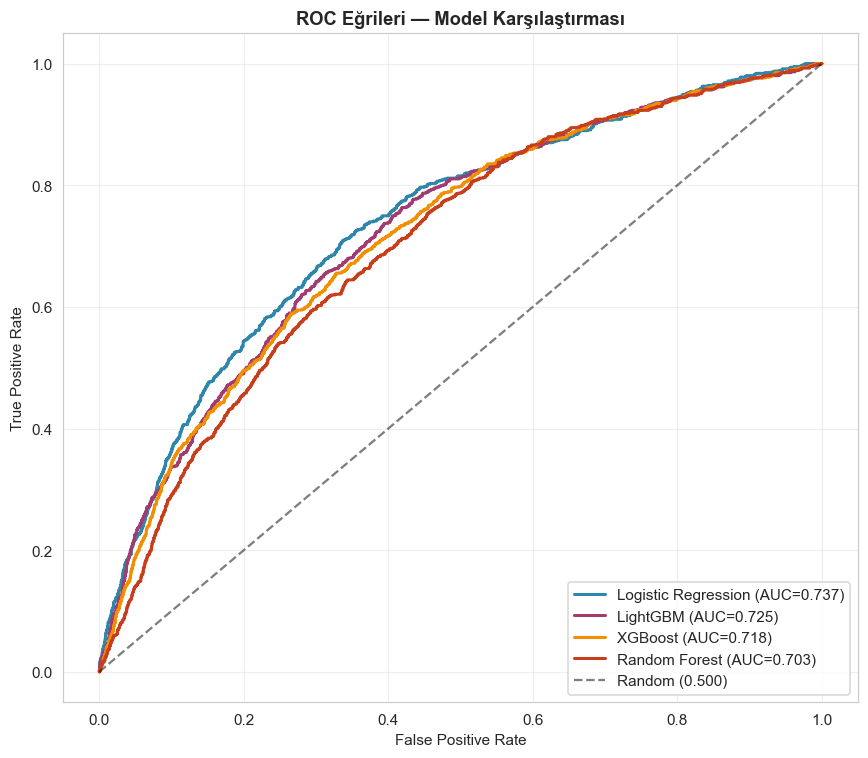

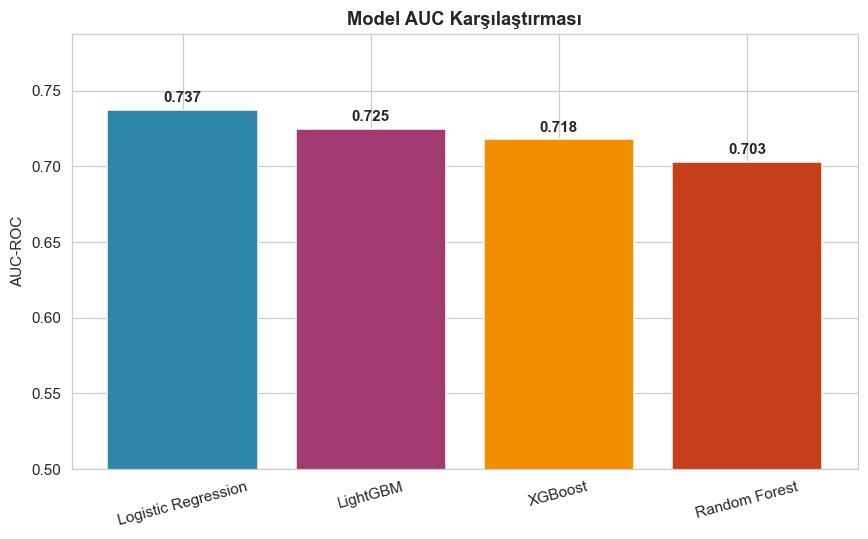

In [5]:
renkler=["#2E86AB","#A23B72","#F18F01","#C73E1D"]
plt.figure(figsize=(8,7))
for (name,(fpr,tpr,auc)),c in zip(sorted(roc_data.items(),key=lambda x:-x[1][2]),renkler):
    plt.plot(fpr,tpr,label=f"{name} (AUC={auc:.3f})",lw=2,color=c)
plt.plot([0,1],[0,1],"k--",alpha=0.5,label="Random (0.500)")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Eğrileri — Model Karşılaştırması",fontweight="bold")
plt.legend(loc="lower right"); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/model_roc_comparison.png",dpi=150,bbox_inches="tight"); plt.show()

plt.figure(figsize=(8,5))
aucv=results_df["AUC-ROC"].values
b=plt.bar(results_df.index,aucv,color=renkler[:len(results_df)])
plt.ylabel("AUC-ROC"); plt.title("Model AUC Karşılaştırması",fontweight="bold")
plt.ylim(0.5,max(aucv)+0.05)
for bar,v in zip(b,aucv): plt.text(bar.get_x()+bar.get_width()/2,v+0.005,f"{v:.3f}",ha="center",fontweight="bold")
plt.xticks(rotation=15); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/model_auc_comparison.png",dpi=150,bbox_inches="tight"); plt.show()

## 6. Confusion Matrix (optimal threshold ile)

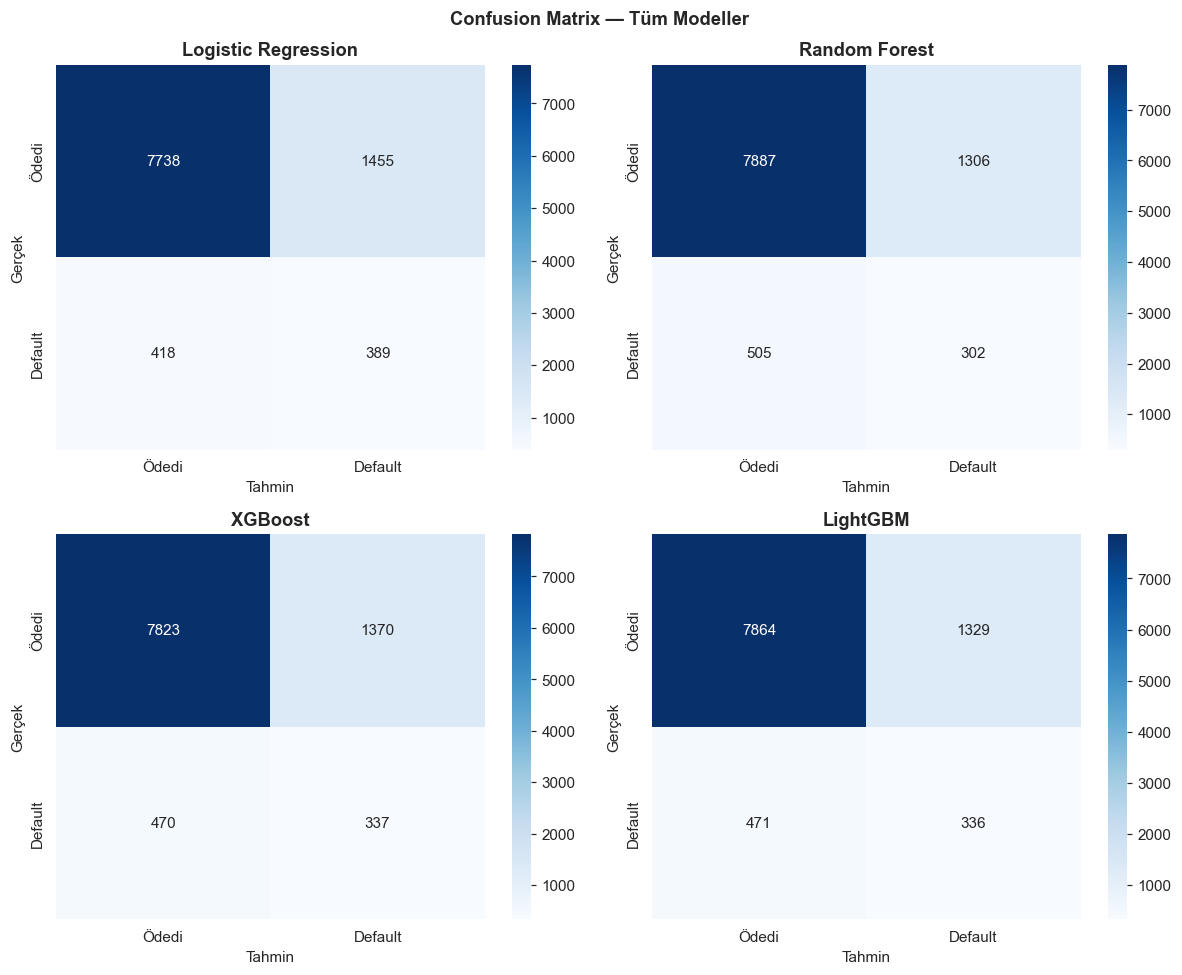

In [6]:
fig,axes=plt.subplots(2,2,figsize=(11,9))
for (name,model),ax in zip(trained.items(),axes.ravel()):
    proba=model.predict_proba(X_test)[:,1]; pred=(proba>=thresholds[name]).astype(int)
    cm=confusion_matrix(y_test,pred)
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",ax=ax,
                xticklabels=["Ödedi","Default"],yticklabels=["Ödedi","Default"])
    ax.set_title(f"{name}",fontweight="bold"); ax.set_ylabel("Gerçek"); ax.set_xlabel("Tahmin")
plt.suptitle("Confusion Matrix — Tüm Modeller",fontweight="bold"); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/model_confusion_all.png",dpi=150,bbox_inches="tight"); plt.show()

## 7. İstatistiksel Anlamlılık Testi (Paired t-test + Bonferroni)

Methodology 5.5: model çiftlerinin 5-fold CV AUC skorları paired t-test ile karşılaştırılır,
çoklu karşılaştırma için Bonferroni düzeltmesi uygulanır.

In [7]:
names=list(cv_scores.keys())
n_comp=len(list(combinations(names,2))); alpha=0.05/n_comp
rows=[]
for m1,m2 in combinations(names,2):
    t,p=stats.ttest_rel(cv_scores[m1],cv_scores[m2])
    rows.append({"Model 1":m1,"Model 2":m2,
        "Mean Diff":round(cv_scores[m1].mean()-cv_scores[m2].mean(),4),
        "t-stat":round(t,3),"p-value":round(p,4),
        "Significant":"EVET" if p<alpha else "Hayir"})
stat_df=pd.DataFrame(rows); stat_df.to_csv(f"{RES_DIR}/statistical_tests.csv",index=False)
print(f"Bonferroni alpha = 0.05/{n_comp} = {alpha:.4f}\n")
print(stat_df.to_string(index=False))

Bonferroni alpha = 0.05/6 = 0.0083

            Model 1       Model 2  Mean Diff  t-stat  p-value Significant
Logistic Regression Random Forest     0.0289  16.101   0.0001        EVET
Logistic Regression       XGBoost     0.0131   6.273   0.0033        EVET
Logistic Regression      LightGBM     0.0072   2.844   0.0467       Hayir
      Random Forest       XGBoost    -0.0158 -12.939   0.0002        EVET
      Random Forest      LightGBM    -0.0217 -10.207   0.0005        EVET
            XGBoost      LightGBM    -0.0059  -5.081   0.0071        EVET


## 8. SHAP Analizi (en iyi model — Methodology 5.5)

Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.


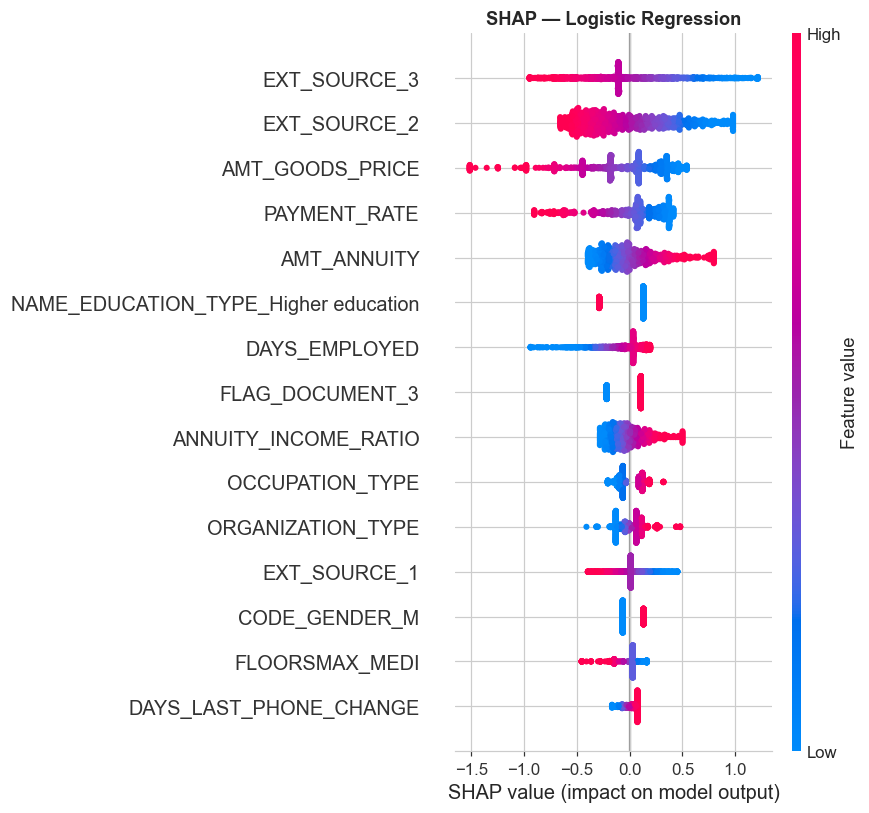

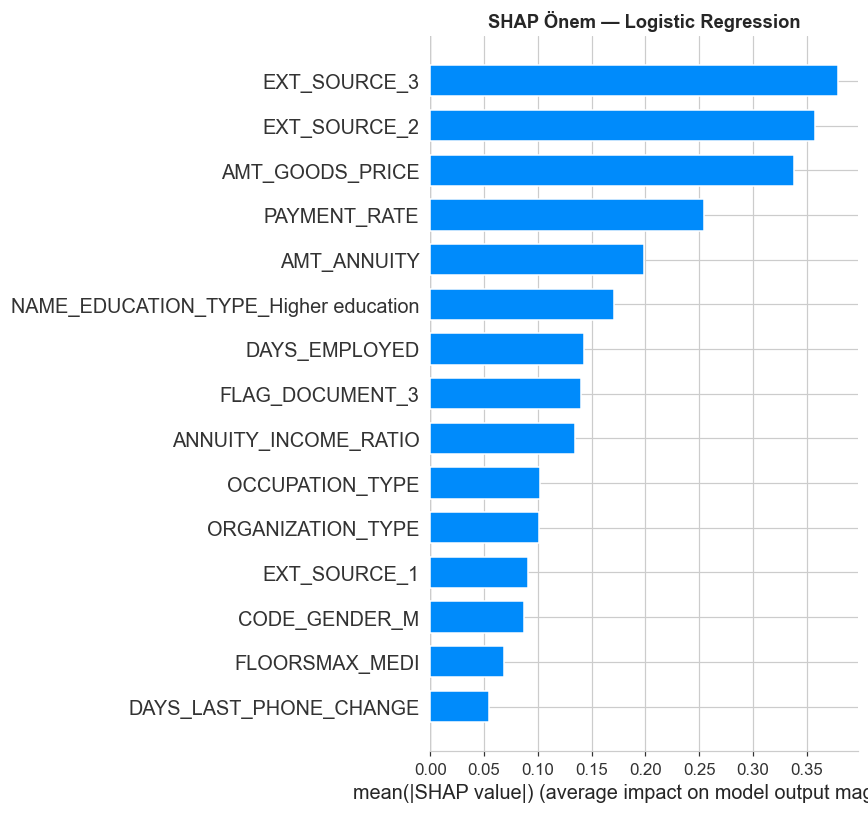

SHAP grafikleri kaydedildi.


In [8]:
import shap
best=trained[best_model_name]
clf=best.named_steps["clf"]
# Pipeline'in clf-oncesi adimlarini test verisine uygula (SMOTE transform'da bypass edilir)
X_shap=X_test.sample(min(1000,len(X_test)),random_state=RANDOM_STATE)
try:
    if "sc" in best.named_steps:   # LogReg: scaler uygula + LinearExplainer
        Xs=pd.DataFrame(best.named_steps["sc"].transform(X_shap),columns=X_shap.columns,index=X_shap.index)
        explainer=shap.LinearExplainer(clf,Xs); sv=explainer.shap_values(Xs); Xplot=Xs
    else:                          # Tree: TreeExplainer dogrudan
        explainer=shap.TreeExplainer(clf); sv=explainer.shap_values(X_shap)
        if isinstance(sv,list): sv=sv[1]
        Xplot=X_shap
    plt.figure(); shap.summary_plot(sv,Xplot,show=False,max_display=15)
    plt.title(f"SHAP — {best_model_name}",fontweight="bold"); plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/shap_summary.png",dpi=150,bbox_inches="tight"); plt.show()
    plt.figure(); shap.summary_plot(sv,Xplot,plot_type="bar",show=False,max_display=15)
    plt.title(f"SHAP Önem — {best_model_name}",fontweight="bold"); plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/shap_bar.png",dpi=150,bbox_inches="tight"); plt.show()
    print("SHAP grafikleri kaydedildi.")
except Exception as e:
    print("SHAP hatasi:",e)